Analysing data of Global tech talent and workforce survey gotten from kaggle.com

In [1]:
#first steps:
#importing libraries to work with the dataset

import pandas as pd
import numpy as np

df = pd.read_csv('saas-sample-500.csv')
#checking the dataset
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   productId          354 non-null    str  
 1   name               354 non-null    str  
 2   tagline            354 non-null    str  
 3   description        354 non-null    str  
 4   url                354 non-null    str  
 5   websiteUrl         354 non-null    str  
 6   avatarUrl          354 non-null    str  
 7   monthlyRevenueUSD  354 non-null    int64
 8   numFollowers       354 non-null    int64
 9   twitterHandle      124 non-null    str  
 10  startDate          354 non-null    str  
 11  createdAt          354 non-null    str  
 12  publishedAt        354 non-null    str  
 13  updatedAt          354 non-null    str  
 14  founderUserIds     354 non-null    str  
 15  verticals          354 non-null    str  
 16  revenueModels      354 non-null    str  
 17  funding            354 non-

In [2]:
#setting data types for the columns
datecols = ['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
print(f"{datecols}\nthe date columns")
df[datecols] = df[datecols].apply(pd.to_datetime, errors='coerce', format='ISO8601')
category_columns = df.select_dtypes(include = 'str').columns.tolist()
numeric_columns = df.select_dtypes(include = 'int64').columns.tolist()
timeseries_columns = df.select_dtypes(exclude=['object', 'int64', 'float64']).columns.tolist()
print(f"Category columns: {category_columns}")
print(f"Numeric columns: {numeric_columns}")
print(f"Timeseries columns: {timeseries_columns}")
# df.info()
#checking for missing values
missing_values = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print(f"Missing values (%): \n{missing_values}")
# fill missing values in the handle and platform columns with 'Unknown'
df.fillna({'twitterHandle': 'Unknown', 'platforms': 'Unknown'}, inplace=True)
print(df.columns)
keycolumns = ['productId', 'url', 'tagline', 'monthlyRevenueUSD', 'numFollowers', 'platforms', 'revenueModels', 'verticals', 'funding', 'startDate', 'createdAt', 'publishedAt', 'scrapedAt']
summarydf_stats = df[keycolumns].describe().transpose() #generating summary statistics for the key columns of the dataset
categorical_summary =  df[keycolumns].describe(include='object').transpose() #generating summary statistics for the categorical columns of the dataset
print(f"Summary statistics for key columns: \n{summarydf_stats}")
print(f"Summary statistics for categorical columns: \n{categorical_summary}")
updated_df = df[keycolumns] #creating a new dataframe with only the key columns for further analysis

['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
the date columns
Category columns: ['productId', 'name', 'tagline', 'description', 'url', 'websiteUrl', 'avatarUrl', 'twitterHandle', 'updatedAt', 'founderUserIds', 'verticals', 'revenueModels', 'funding', 'platforms', 'allTags']
Numeric columns: ['monthlyRevenueUSD', 'numFollowers']
Timeseries columns: ['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
Missing values (%): 
twitterHandle        64.971751
platforms             2.542373
tagline               0.000000
name                  0.000000
productId             0.000000
url                   0.000000
description           0.000000
monthlyRevenueUSD     0.000000
websiteUrl            0.000000
numFollowers          0.000000
startDate             0.000000
createdAt             0.000000
avatarUrl             0.000000
publishedAt           0.000000
updatedAt             0.000000
verticals             0.000000
founderUserIds        0.000000
revenueModels         0.000000
fundin

C:\Users\ibien\AppData\Local\Temp\ipykernel_19788\1256896964.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_summary =  df[keycolumns].describe(include='object').transpose() #generating summary statistics for the categorical columns of the dataset


In [3]:
total_observations = len(df)
print(f'Total observations: {total_observations}')

average_monthly_revenue = df['monthlyRevenueUSD'].mean()
median_monthly_revenue = df['monthlyRevenueUSD'].median()
max_monthly_revenue = df['monthlyRevenueUSD'].max()
total_monthly_revenue = df['monthlyRevenueUSD'].sum()
lowest_monthly_revenue = df['monthlyRevenueUSD'].min()
print(f'Total monthly revenue: ${total_monthly_revenue:,.2f} and the maximum monthly revenue is ${max_monthly_revenue:,.2f} and the lowest monthly revenue is ${lowest_monthly_revenue:,.2f}')
print(f'Average monthly revenue: ${average_monthly_revenue:,.2f} but the realistic rate a person is making is ${median_monthly_revenue:.2f} per month')
average_followers = df['numFollowers'].mean().round(0)
median_followers = df['numFollowers'].median().round(0)
total_followers = df['numFollowers'].sum()
print(f'The Average number of followers a person has is {average_followers}\n total followers across all repondendts is {total_followers}')
df['startDate'].dt.to_period('Y').value_counts()
low_earners =df[df['monthlyRevenueUSD'] == 0].count()
print(f'The number of low earners (earning $0 or less) is {low_earners["monthlyRevenueUSD"]}')
earning_bar = {'low earners':df['monthlyRevenueUSD'].quantile(0.25), 'average earners': df['monthlyRevenueUSD'].quantile(0.5), 'high earners': df['monthlyRevenueUSD'].quantile(0.75)}
print(f"Earning distribution: \n{earning_bar}")

Total observations: 354
Total monthly revenue: $568,711,116.00 and the maximum monthly revenue is $567,890,678.00 and the lowest monthly revenue is $0.00
Average monthly revenue: $1,606,528.58 but the realistic rate a person is making is $0.00 per month
The Average number of followers a person has is 1.0
 total followers across all repondendts is 353
The number of low earners (earning $0 or less) is 247
Earning distribution: 
{'low earners': np.float64(0.0), 'average earners': np.float64(0.0), 'high earners': np.float64(11.5)}


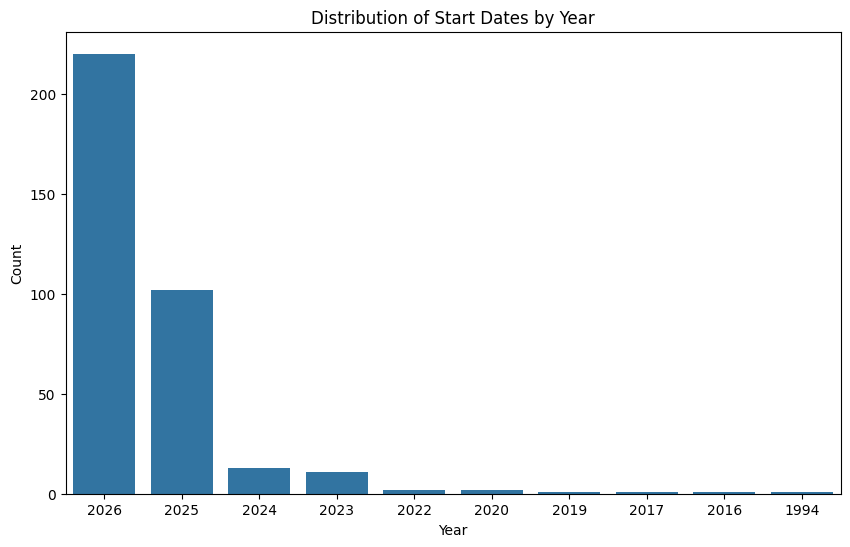

Monthly revenue buckets: 
monthlyRevenueUSD
$0            247
$1-$1K         80
$1K-$10K       19
$10K-$100K      6
$100K-$1M       1
$1M+            1
Name: count, dtype: int64


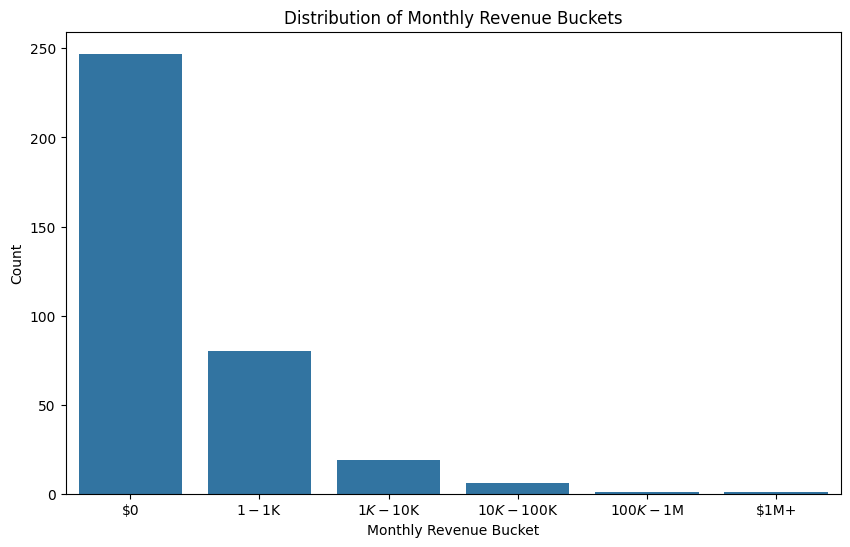

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# plt.figure(figsize=(10, 6))
# sns.histplot(df['monthlyRevenueUSD'], bins=30, kde=True)
# plt.title('Distribution of Monthly Revenue (USD)')
# plt.xlabel('Monthly Revenue (USD)')
# plt.ylabel('Frequency')
# plt.show()
startDate_summary = df.pivot_table(index='startDate', aggfunc = 'size').sort_values(ascending = False)
startDate_summary
plt.figure(figsize=(10, 6))
sns.barplot(x=df['startDate'].dt.to_period('Y').value_counts().index.astype(str).sort_values(ascending=False), y=df['startDate'].dt.to_period('Y').value_counts().values)
plt.title('Distribution of Start Dates by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

monthly_revenue_buckets = pd.cut(df['monthlyRevenueUSD'], bins=[-1, 0, 1000, 10000, 100000, 1000000, df['monthlyRevenueUSD'].max()], labels=['$0', '$1-$1K', '$1K-$10K', '$10K-$100K', '$100K-$1M', '$1M+'])
print(f"Monthly revenue buckets: \n{monthly_revenue_buckets.value_counts()}")
plt.figure(figsize=(10, 6))
sns.countplot(x=monthly_revenue_buckets, order=monthly_revenue_buckets.value_counts().index)
plt.title('Distribution of Monthly Revenue Buckets')
plt.xlabel('Monthly Revenue Bucket')
plt.ylabel('Count')
plt.show()

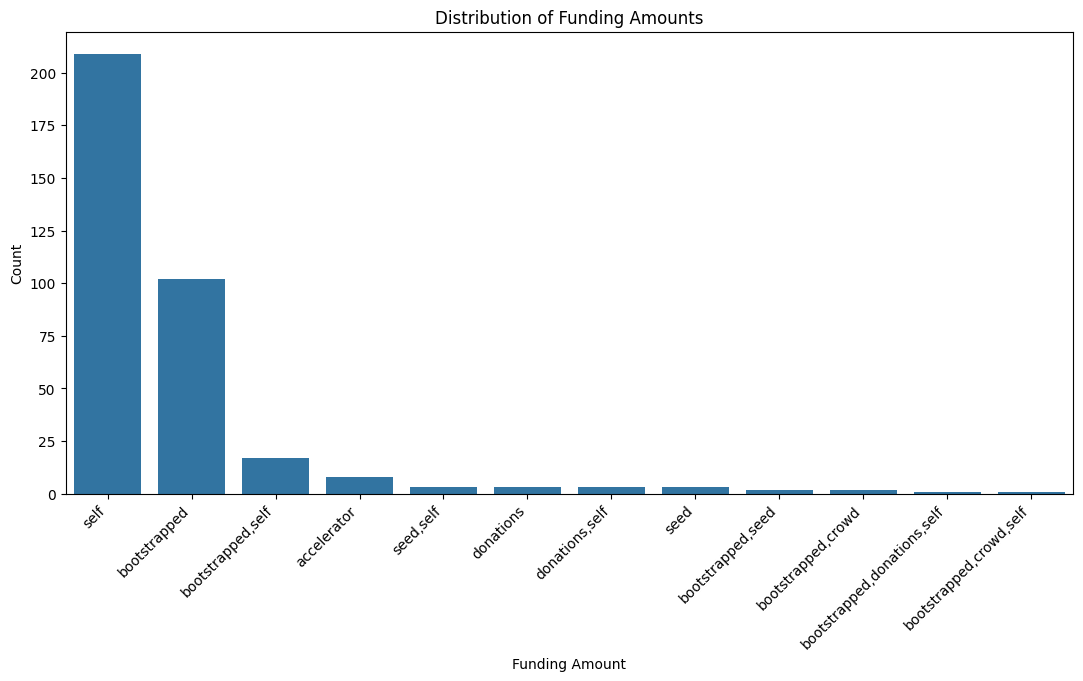

funding
self                           209
bootstrapped                   102
bootstrapped,self               17
accelerator                      8
seed                             3
seed,self                        3
donations,self                   3
donations                        3
bootstrapped,seed                2
bootstrapped,crowd               2
bootstrapped,crowd,self          1
bootstrapped,donations,self      1
dtype: int64

In [5]:
funding_split = df['funding'].value_counts()
# print(f"Funding distribution: \n{funding_split}")
funding_summary = df.pivot_table(index='funding', aggfunc = 'size').sort_values(ascending = False)
plt.figure(figsize=(13, 6))
sns.barplot(x=funding_split.index, y=funding_split.values)
plt.title('Distribution of Funding Amounts')
plt.xlabel('Funding Amount')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()
funding_summary

In [6]:
df['funding'].value_counts()

funding
self                           209
bootstrapped                   102
bootstrapped,self               17
accelerator                      8
seed,self                        3
donations                        3
donations,self                   3
seed                             3
bootstrapped,seed                2
bootstrapped,crowd               2
bootstrapped,donations,self      1
bootstrapped,crowd,self          1
Name: count, dtype: int64

**Revenue models and platforms**
Analysis below

In [7]:
# print('distribution of platform performance \n',df['platforms'].value_counts())
platforms_summary = df.pivot_table(index='platforms', aggfunc = 'size').sort_values(ascending = False)
platforms_summary

platforms
web                                              156
mobile,web                                        22
android,desktop,ios,mac,mobile,pc,web             20
android,browser,desktop,ios,mac,mobile,pc,web     11
ios                                               11
desktop                                           10
Unknown                                            9
pc,web                                             8
desktop,mobile,web                                 8
android                                            7
ios,mac                                            7
browser,web                                        6
desktop,pc,web                                     6
desktop,mobile,pc,web                              5
desktop,mac,mobile,pc,web                          4
mac                                                4
android,ios,mobile,web                             4
ios,mobile                                         4
mobile,pc,web                       

In [8]:
revenue_models_summary = df.pivot_table(index='revenueModels', aggfunc = 'size').sort_values(ascending = False)
revenue_models_summary

revenueModels
subscription                                                                      154
free                                                                               55
transactional                                                                      31
free,subscription                                                                  30
subscription,transactional                                                          8
advertising                                                                         8
commission                                                                          6
advertising,free                                                                    5
advertising,subscription                                                            5
free,subscription,transactional                                                     5
advertising,free,subscription                                                       4
consulting                              

**Analysis**

The report is based on 354 observations of Global Talent and Workforce data.
Based on the analysis conducted, it was observed that over five hundred million dollars was recorded as monthly income over the period. Further analysis revealed a heavy skew in the composition as a vast majority of the observed population did not earn any money, it was a revealed that an individual earned $567,890,678 while 247 persons did not receive any money.

Analysis also revealed that over 200 (almost 60%) persons utilised personal funds to finance their operations.
In terms of platforms used by observed participants, web applications top the list, while subscription models was the prefered revenue model adopted.

It is also important to highlight that, there has been a progress rate of adoption from the general public as the numbers of participants have increased from the maiden edition in 1994, though the breakthrough was recorded in 2023 with a 65% growth from the previous period.
